Notebook 2: Calibração das AOIs via estímulo original
 Resolução do monitor detectada pelos dados: 1920x1080 pixels.
📐 Tamanho da imagem do estímulo: 1441x1077 pixels.


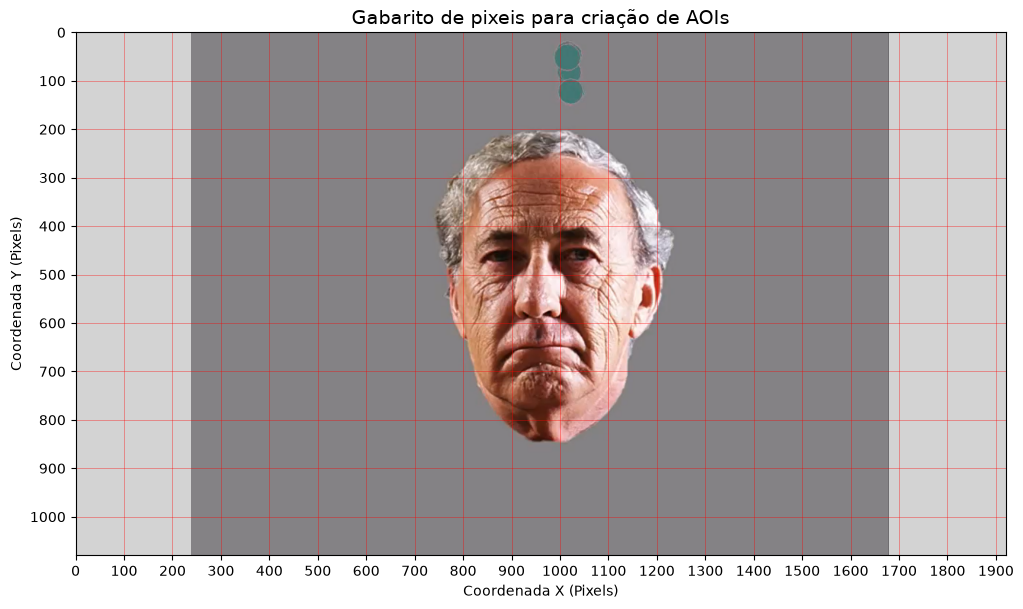


INSTRUÇÕES:
Observe a imagem acima e anote as coordenadas aproximadas (X Mínimo, X Máximo, Y Mínimo, Y Máximo) para:
1. Olho Esquerdo
2. Olho Direito
3. Nariz
4. Boca
5. Rosto (Contorno total)


In [2]:
# MAPEAMENTO ESPACIAL DE AOIS

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Notebook 2: Calibração das AOIs via estímulo original")
print("="*80)

# Descoberta da resolução do monitor
PASTA_CSV = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_CSV, '*.csv'))

max_x_global = 0
max_y_global = 0

# Olha os primeiros 5 pacientes para ter certeza do limite da tela
for caminho in arquivos_limpos[:5]:
    try:
        df = pd.read_csv(caminho)
        max_x = df['Gaze_X'].max()
        max_y = df['Gaze_Y'].max()
        if max_x > max_x_global: max_x_global = max_x
        if max_y > max_y_global: max_y_global = max_y
    except:
        pass

# Arredonda para a resolução comercial mais próxima (ex: 1278 vira 1280)
RESOLUCAO_TELA = (int(np.ceil(max_x_global/10)*10), int(np.ceil(max_y_global/10)*10))
print(f" Resolução do monitor detectada pelos dados: {RESOLUCAO_TELA[0]}x{RESOLUCAO_TELA[1]} pixels.")

# 1. Caminho imagem
CAMINHO_IMAGEM = '/workspaces/EyeTracking/data/videos/imagem_de_rosto.png'

# 2. Resolução do monitor usado na coleta
RESOLUCAO_TELA = (1920, 1080) 

try:
    img = mpimg.imread(CAMINHO_IMAGEM)
    
    # Assumindo que a imagem estava centralizada no ecrã.
    # Cálculo de onde ela foi desenhada.
    alt_img, larg_img = img.shape[0], img.shape[1]
    print(f"📐 Tamanho da imagem do estímulo: {larg_img}x{alt_img} pixels.")
    
    x_offset = (RESOLUCAO_TELA[0] - larg_img) // 2
    y_offset = (RESOLUCAO_TELA[1] - alt_img) // 2

    # Cria a figura simulando o ecrã inteiro
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Desenhar um fundo preto/cinzento (simulando a janela)
    ax.set_xlim(0, RESOLUCAO_TELA[0])
    ax.set_ylim(RESOLUCAO_TELA[1], 0) # Eixo Y invertido em Eye Tracking
    ax.set_facecolor('lightgrey')
    
    # Coloca a imagem exatamente no centro
    ax.imshow(img, extent=[x_offset, x_offset + larg_img, y_offset + alt_img, y_offset])
    
    # Adiciona a grelha fina para podermos ler os pixeis
    ax.grid(color='red', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xticks(np.arange(0, RESOLUCAO_TELA[0], 100))
    ax.set_yticks(np.arange(0, RESOLUCAO_TELA[1], 100))
    
    plt.title("Gabarito de pixeis para criação de AOIs", fontsize=14)
    plt.xlabel("Coordenada X (Pixels)")
    plt.ylabel("Coordenada Y (Pixels)")
    
    plt.show()
    
    print("\nINSTRUÇÕES:")
    print("Observe a imagem acima e anote as coordenadas aproximadas (X Mínimo, X Máximo, Y Mínimo, Y Máximo) para:")
    print("1. Olho Esquerdo")
    print("2. Olho Direito")
    print("3. Nariz")
    print("4. Boca")
    print("5. Rosto (Contorno total)")

except FileNotFoundError:
    print(f" Imagem não encontrada no caminho: {CAMINHO_IMAGEM}")
    print("Por favor, faça o upload de uma imagem do teste, atualize o caminho no código e corra novamente.")

In [4]:
# ADD AOIs NOS DADOS

import os
import glob
import pandas as pd
import numpy as np

print("Adicionando AOIs geométricas nos dados")
print("="*80)

PASTA_CSV = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_CSV, '*.csv'))

# 1. Definição do dicionário de caixas (X_min, X_max, Y_min, Y_max)
aois = {
    'AOI_Olho_Esquerdo': (450, 600, 400, 500),
    'AOI_Olho_Direito':  (650, 800, 400, 500),
    'AOI_Ambos_Olhos':   (450, 800, 400, 500),
    'AOI_Nariz':         (550, 700, 500, 650),
    'AOI_Boca':          (500, 750, 650, 760),
    'AOI_Triangulo':     (450, 800, 400, 650),
    'AOI_Rosto':         (300, 950, 150, 850)
}

contador = 0

for caminho in arquivos_limpos:
    nome_puro = os.path.basename(caminho).replace('.csv', '')
    
    try:
        df = pd.read_csv(caminho)
        
        # Garante que temos Gaze numérico para não dar erro na matemática
        df['Gaze_X'] = pd.to_numeric(df['Gaze_X'], errors='coerce')
        df['Gaze_Y'] = pd.to_numeric(df['Gaze_Y'], errors='coerce')
        
        # 2. Aplicação das Máscaras (True/False) para cada AOI
        for nome_aoi, (xmin, xmax, ymin, ymax) in aois.items():
            # Só marcamos se o Gaze X e Y não forem nulos (piscar de olhos/ruído)
            df[nome_aoi] = (
                (df['Gaze_X'] >= xmin) & (df['Gaze_X'] <= xmax) &
                (df['Gaze_Y'] >= ymin) & (df['Gaze_Y'] <= ymax)
            )
            
        # 3. Definição da AOI 'fora' (Se não está no Rosto, mas o olho foi rastreado, está fora)
        df['AOI_Fora'] = (~df['AOI_Rosto']) & (df['Gaze_X'].notnull()) & (df['Gaze_Y'].notnull())
        
        # Salvar o CSV atualizado
        df.to_csv(caminho, index=False)
        contador += 1
        
    except Exception as e:
        print(f"❌ Erro ao processar '{nome_puro}': {e}")

print(f" Mapeamento espacial concluído para {contador} pacientes!")
print("As variáveis clínicas (AOIs) foram adicionadas com sucesso e sobrepuseram o ruído nativo do equipamento.")

Adicionando AOIs geométricas nos dados


 Mapeamento espacial concluído para 38 pacientes!
As variáveis clínicas (AOIs) foram adicionadas com sucesso e sobrepuseram o ruído nativo do equipamento.
